In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv("Quikr_car.csv")
df

,Unnamed: 0,Name,Label,Location,Price,Kms_driven,Fuel_type,Owner,Year,Company
0,0,Ford Figo Duratec Petrol EXI 1.2 - 2015,PLATINUM,Bangalore,"₹3,80,000","35,056 kms",Petrol,NaN,2015,Ford
1,1,Maruti Suzuki Wagon R VXI BS IV - 2016,PLATINUM,Bangalore,"₹4,65,000","44,000 kms",Petrol,NaN,2016,Maruti
2,2,Hyundai Creta 1.6 SX PLUS AUTO PETROL - 2018,PLATINUM,Bangalore,"₹13,50,000","42,917 kms",Petrol,NaN,2018,Hyundai
3,3,Hyundai Venue - 2019,PLATINUM,Chennai,"₹10,19,699","16,112 kms",Petrol,2nd Owner,2019,Hyundai
4,4,Honda Jazz - 2017,PLATINUM,Pune,"₹7,13,499","30,988 kms",Petrol,2nd Owner,2017,Honda
...,...,...,...,...,...,...,...,...,...,...
1027,1027,Hyundai i10 Magna 1.2 - 2014,GOLD,Bangalore,"₹2,29,000","65,000 kms",Petrol,1st Owner,2014,Hyundai
1028,1028,Maruti Suzuki Alto K10 LXi CNG - 2014,GOLD,Bangalore,"₹2,75,000","60,000 kms",Petrol,NaN,2014,Maruti
1029,1029,Jeep Compass Limited 2.0 Diesel - 2017,GOLD,Mahasamund,"₹17,50,000","31,000 kms",Diesel,1st Owner,2017,Jeep
1030,1030,Jeep Compass Limited 2.0 Diesel - 2017,GOLD,Bilaspur,"₹17,50,000","31,000 kms",Diesel,1st Owner,2017,Jeep


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1032 non-null   int64 
 1   Name        1032 non-null   object
 2   Label       1032 non-null   object
 3   Location    1030 non-null   object
 4   Price       1032 non-null   object
 5   Kms_driven  1032 non-null   object
 6   Fuel_type   1032 non-null   object
 7   Owner       740 non-null    object
 8   Year        1032 non-null   int64 
 9   Company     1032 non-null   object
dtypes: int64(2), object(8)
memory usage: 80.8+ KB


In [27]:
df.isnull().sum()

Unnamed: 0      0
Name            0
Label           0
Location        2
Price           0
Kms_driven      0
Fuel_type       0
Owner         292
Year            0
Company         0
dtype: int64

In [28]:
df["Price"] = df["Price"].str.replace("₹", "", regex=False)
df["Price"] = df["Price"].str.replace(",", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [32]:
df = df.dropna(subset=["Price"])

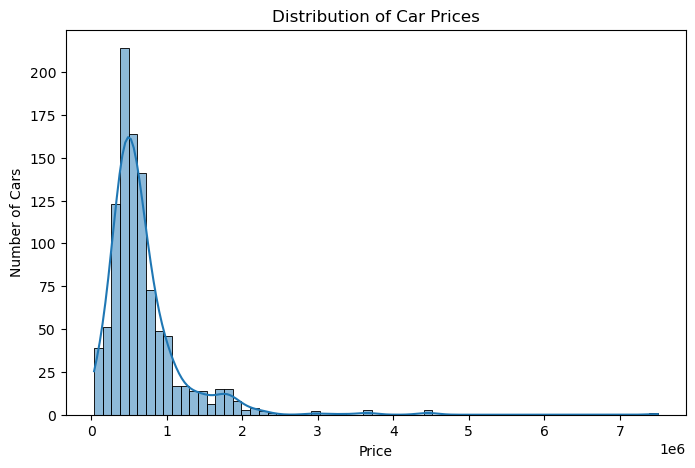

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")

plt.show()

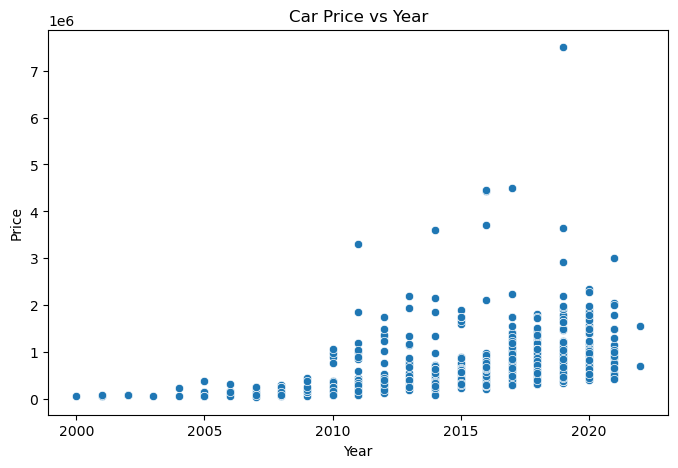

In [34]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Year", y="Price")

plt.title("Car Price vs Year")

plt.show()

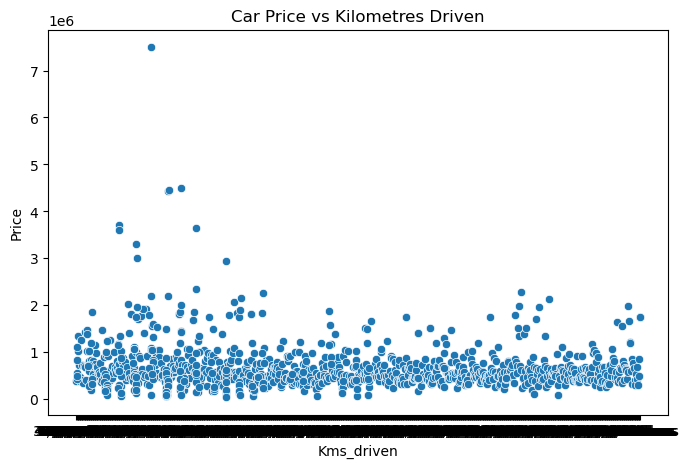

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Kms_driven", y="Price")

plt.title("Car Price vs Kilometres Driven")

plt.show()

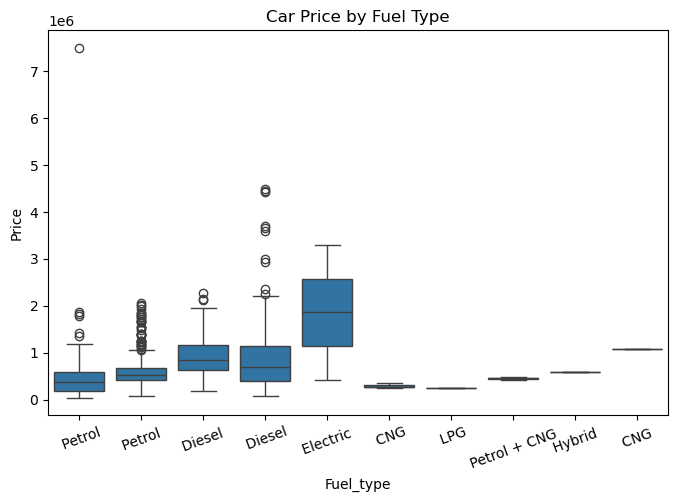

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Fuel_type", y="Price")

plt.title("Car Price by Fuel Type")

plt.xticks(rotation=20)

plt.show()

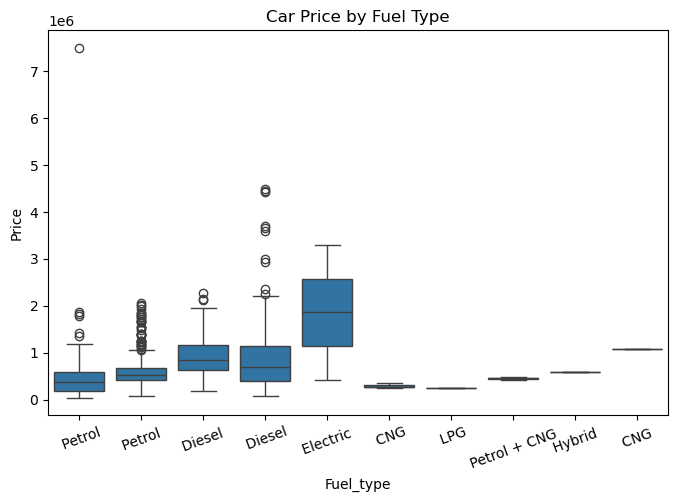

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Fuel_type", y="Price")

plt.title("Car Price by Fuel Type")

plt.xticks(rotation=20)

plt.show()

In [39]:
X = df.drop("Price", axis=1)
y = df["Price"]

print("X:", X.shape)
print("y:", y.shape)

X: (1026, 9)
y: (1026,)


In [40]:
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

print("Categorical:", list(categorical_columns))
print("Numerical:", list(numerical_columns))

Categorical: ['Name', 'Label', 'Location', 'Kms_driven', 'Fuel_type', 'Owner', 'Company']
Numerical: ['Unnamed: 0', 'Year']


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (820, 9)
Testing: (206, 9)


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [43]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [44]:
from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
MAE : 199966.05852154718
RMSE: 438612.79849272483
R²  : 0.5610382892687826


In [48]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)

Decision Tree
MAE : 243209.26213592233
RMSE: 578903.3445785011
R²  : 0.23532629357816182


In [49]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 197937.52463592234
RMSE: 531819.5339332594
R²  : 0.3546540188085523


In [50]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,199966.058522,438612.798493,0.561038
1,Decision Tree,243209.262136,578903.344579,0.235326
2,Random Forest,197937.524636,531819.533933,0.354654


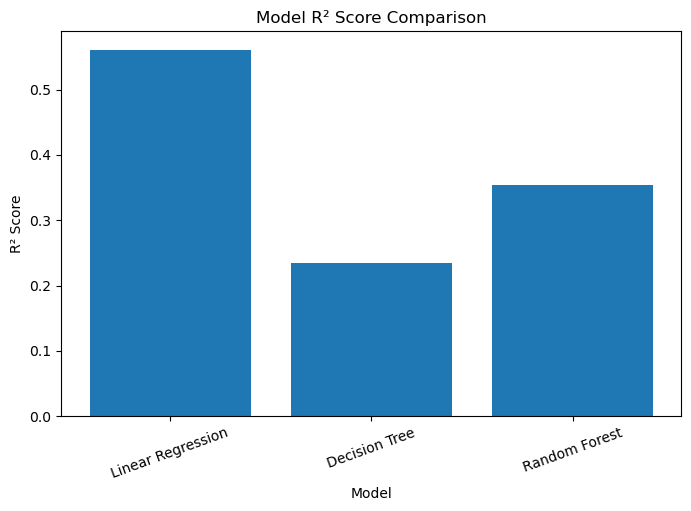

In [52]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model R² Score Comparison")
plt.xticks(rotation=20)

plt.show()

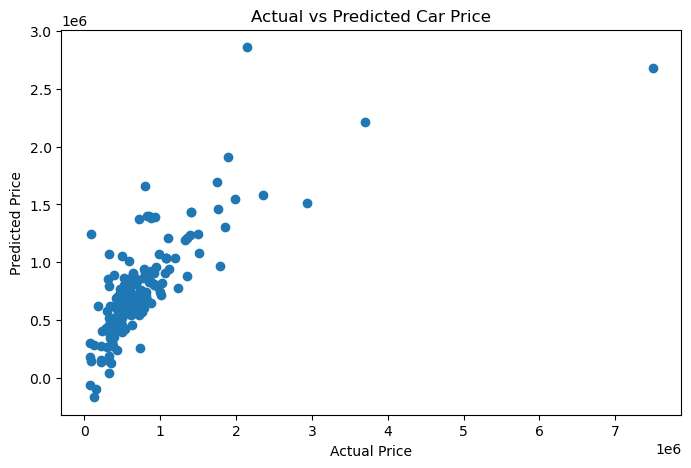

In [53]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, linear_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")

plt.show()